# Convergence of the generalized Newton–Schulz iteration
One matrix, several degrees D. Each iterate is frozen once its error reaches `eps` and the error is held until `k_max`; for a rank-deficient matrix keep `eps` above the noise floor (about $u/\sigma_{\min}$). Edit the config and rerun.

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so ns_core and experiments import

import matplotlib.pyplot as plt
import torch

from ns_core import plots
from experiments.convergence import ConvergenceConfig, run_convergence
%matplotlib inline

In [38]:
cfg = ConvergenceConfig(
    m=256, n=256, rank=None, smin=1e-1, degrees=[3],
    k_max=10,     # steps run at most
    eps=None,    # freeze the iterate once its error reaches this; None = 10 machine eps
                  # (rank-deficient: keep eps above the noise floor, about u / smin)
    dtype=torch.float64, device="cuda", seed=0,
)
print(torch.finfo(cfg.dtype).eps)
res = run_convergence(cfg)

2.220446049250313e-16


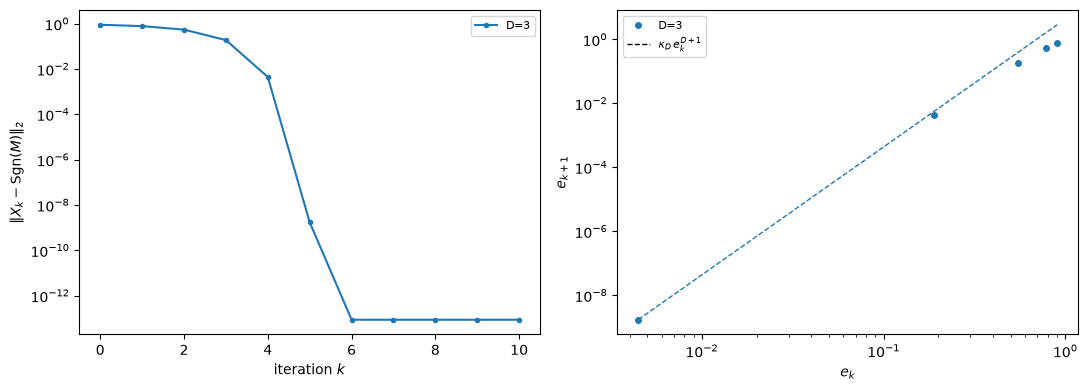

In [39]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
plots.plot_error_curves(res["error"], ax=axs[0])
plots.plot_error_map(res["error"], ax=axs[1])
fig.tight_layout()